### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Problems

Use the prompts below to get started with your data analysis.  

## 1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

## 2. Investigate the dataset for missing or problematic data.

In [ ]:
# Count missing values
missing_counts = data.isnull().sum()

# Calc percentage missing
missing_percent = (data.isnull().sum() / len(data)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

print(missing_df)

                      Missing Count  Missing %
car                           12576  99.148534
CoffeeHouse                     217   1.710817
Restaurant20To50                189   1.490066
CarryAway                       151   1.190476
RestaurantLessThan20            130   1.024913
Bar                             107   0.843582
weather                           0   0.000000
temperature                       0   0.000000
destination                       0   0.000000
passanger                         0   0.000000
maritalStatus                     0   0.000000
age                               0   0.000000
gender                            0   0.000000
expiration                        0   0.000000
coupon                            0   0.000000
time                              0   0.000000
income                            0   0.000000
occupation                        0   0.000000
has_children                      0   0.000000
education                         0   0.000000
toCoupon_GEQ5

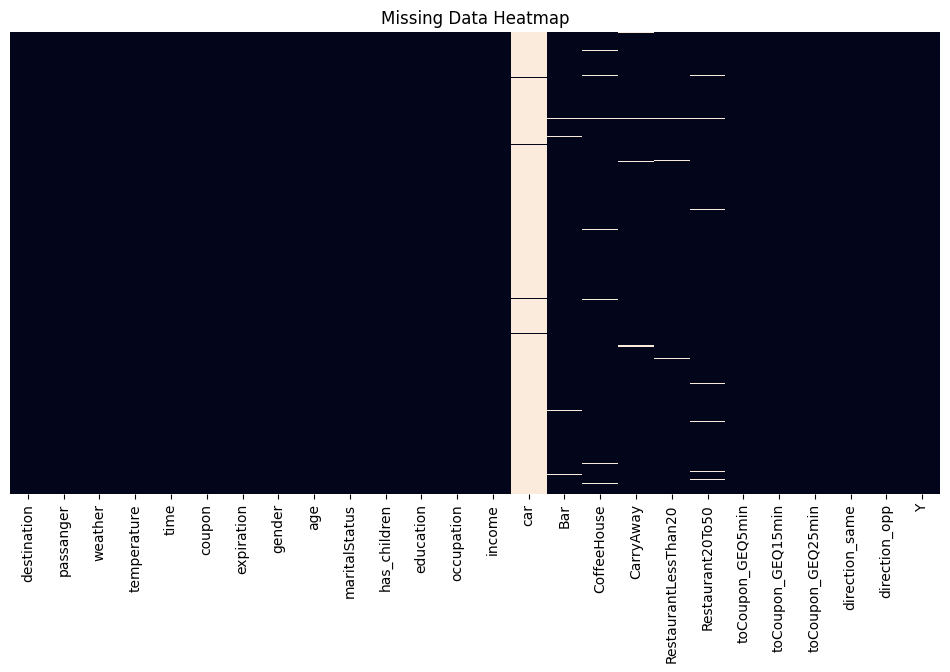

In [ ]:
#missing data in heatmap
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Data Heatmap')
plt.show()

In [ ]:
# Count of unique values in 'car' column, including NaN
data['car'].value_counts(dropna=False)


car
NaN                                         12502
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64

In [ ]:
#Check for Duplicate Rows
duplicates = data.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 74


## 3. Decide what to do about your missing data -- drop, replace, other...

In [ ]:


# The column is too sparse to be useful.. best option is to drop it
data = data.drop(columns=['car'])
data = data.drop_duplicates()

In [ ]:
#Inspect Categorical Variables
for col in data.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(data[col].value_counts(dropna=False))


Column: destination
destination
No Urgent Place    6266
Home               3230
Work               3114
Name: count, dtype: int64

Column: passanger
passanger
Alone        7248
Friend(s)    3292
Partner      1069
Kid(s)       1001
Name: count, dtype: int64

Column: weather
weather
Sunny    10011
Snowy     1397
Rainy     1202
Name: count, dtype: int64

Column: time
time
6PM     3220
7AM     3114
10AM    2271
2PM     2006
10PM    1999
Name: count, dtype: int64

Column: coupon
coupon
Coffee House             3989
Restaurant(<20)          2779
Carry out & Take away    2344
Bar                      2010
Restaurant(20-50)        1488
Name: count, dtype: int64

Column: expiration
expiration
1d    7031
2h    5579
Name: count, dtype: int64

Column: gender
gender
Female    6469
Male      6141
Name: count, dtype: int64

Column: age
age
21         2642
26         2548
31         2019
50plus     1781
36         1317
41         1089
46          670
below21     544
Name: count, dtype: int64

Column:

C:\Users\Adviti Mohan\AppData\Local\Temp\ipykernel_29560\2219757841.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include='object').columns:


In [12]:
#Check Numeric Columns for Outliers or Invalid Values
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12610.000000,12610.000000,12610.0,12610.000000,12610.000000,12610.000000,12610.000000,12610.000000
mean,63.267248,0.414512,1.0,0.559794,0.116019,0.215543,0.784457,0.567565
std,19.153386,0.492657,0.0,0.496432,0.320260,0.411215,0.411215,0.495434
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. What proportion of the total observations chose to accept the coupon?



In [16]:
acceptance_rate = data['Y'].mean()

print("Proportion accepting coupon:", acceptance_rate)

Proportion accepting coupon: 0.5675654242664552


# 5. Use a bar plot to visualize the `coupon` column.

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=data,
    x='coupon',
    order=data['coupon'].value_counts().index,
    palette='viridis'
)

plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

### Findings for Coupon Type Plot
- `Coffee House` coupons are the most frequent type in the dataset.
- `Bar` and `Restaurant(20-50)` coupons are less common, which may influence how models learn from coupon type distribution.

# 6. Use a histogram to visualize the temperature column.

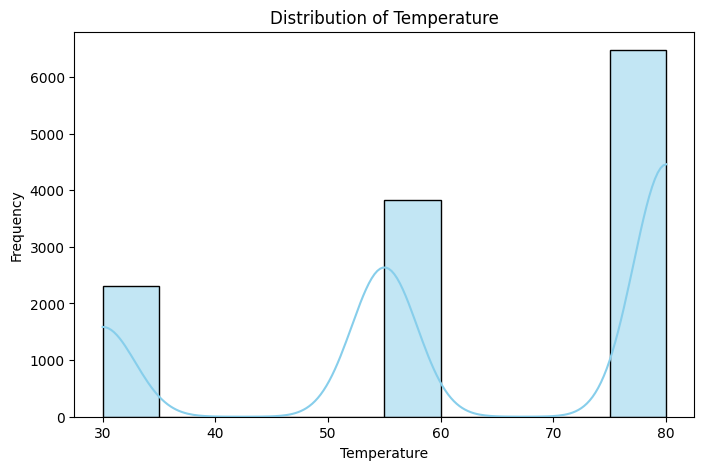

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x='temperature',
    bins=10,
    kde=True,
    color='skyblue'
)

plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')

plt.show()

C:\Users\Adviti Mohan\AppData\Local\Temp\ipykernel_29560\2638228443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


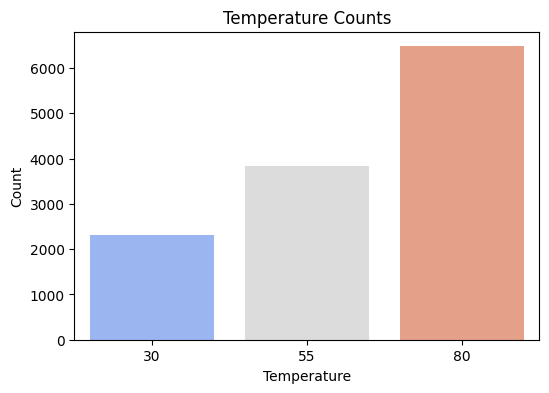

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='temperature',
    palette='coolwarm'
)

plt.title('Temperature Counts')
plt.xlabel('Temperature')
plt.ylabel('Count')

plt.show()

# 7 **Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [26]:
bar_coupons = data[data['coupon'] == 'Bar']
bar_coupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


In [27]:

print(bar_coupons.shape)

(2010, 25)


2. What proportion of bar coupons were accepted?


In [28]:
# You can calculate the proportion of accepted bar coupons using the Y column in the bar_coupons DataFrame.
# the mean of Y gives the acceptance proportion.

bar_acceptance_rate = bar_coupons['Y'].mean()
print("Proportion of bar coupons accepted:", bar_acceptance_rate)

# To display it as a percentage:
print(f"Bar coupon acceptance rate: {bar_acceptance_rate:.2%}")
# You can also see raw counts:
bar_coupons['Y'].value_counts()

Proportion of bar coupons accepted: 0.4099502487562189
Bar coupon acceptance rate: 41.00%


Y
0    1186
1     824
Name: count, dtype: int64

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Acceptance rate (3 or fewer visits): 37.04%
Acceptance rate (more than 3 visits): 76.88%


C:\Users\Adviti Mohan\AppData\Local\Temp\ipykernel_29560\3556420124.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


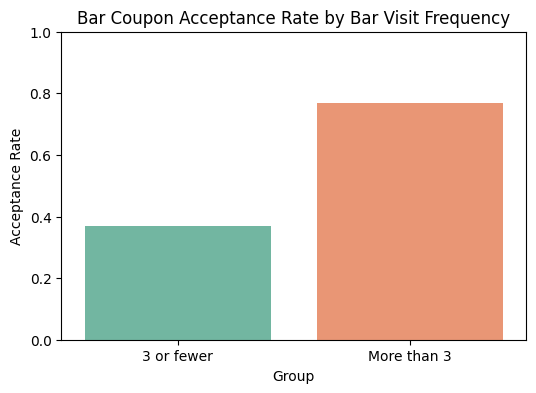

In [31]:
# Drivers who go to bars 3 or fewer times a month
bar_3_or_less = bar_coupons[
    bar_coupons['Bar'].isin(['never', 'less1', '1~3'])
]

# Drivers who go to bars more than 3 times a month
bar_more_than_3 = bar_coupons[
    bar_coupons['Bar'].isin(['4~8', 'gt8'])
]

rate_3_or_less = bar_3_or_less['Y'].mean()
rate_more_than_3 = bar_more_than_3['Y'].mean()

print(f"Acceptance rate (3 or fewer visits): {rate_3_or_less:.2%}")
print(f"Acceptance rate (more than 3 visits): {rate_more_than_3:.2%}")

comparison_df = pd.DataFrame({
    'Group': ['3 or fewer', 'More than 3'],
    'Acceptance Rate': [rate_3_or_less, rate_more_than_3]
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison_df,
    x='Group',
    y='Acceptance Rate',
    palette='Set2'
)

plt.ylim(0,1)
plt.title('Bar Coupon Acceptance Rate by Bar Visit Frequency')
plt.ylabel('Acceptance Rate')

plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Acceptance rate (bar >1/month & age >25): 69.52%
Acceptance rate (all others): 33.46%


C:\Users\Adviti Mohan\AppData\Local\Temp\ipykernel_29560\2476773981.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


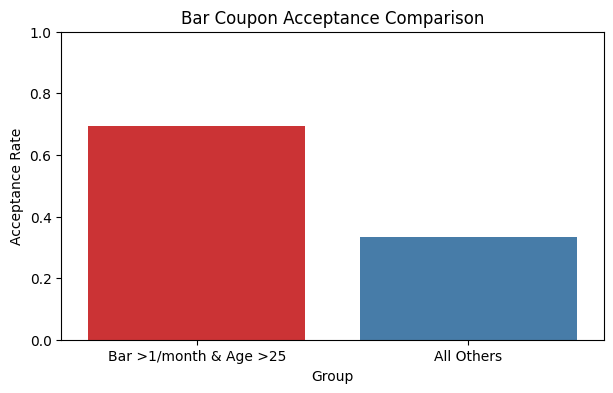

In [34]:
# Group 1: bar visits > once/month AND age > 25
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['age'].isin(['26', '31', '36', '41', '46', '50plus']))
]

# Group 2: all others
group2 = bar_coupons[
    ~(
        (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
        (bar_coupons['age'].isin(['26', '31', '36', '41', '46', '50plus']))
    )
]
group1_rate = group1['Y'].mean()
group2_rate = group2['Y'].mean()

print(f"Acceptance rate (bar >1/month & age >25): {group1_rate:.2%}")
print(f"Acceptance rate (all others): {group2_rate:.2%}")
comparison_df = pd.DataFrame({
    'Group': ['Bar >1/month & Age >25', 'All Others'],
    'Acceptance Rate': [group1_rate, group2_rate]
})

plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison_df,
    x='Group',
    y='Acceptance Rate',
    palette='Set1'
)

plt.ylim(0,1)
plt.title('Bar Coupon Acceptance Comparison')
plt.ylabel('Acceptance Rate')

plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Acceptance rate (target group): 71.32%
Acceptance rate (all others): 29.54%


C:\Users\Adviti Mohan\AppData\Local\Temp\ipykernel_29560\2558472178.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


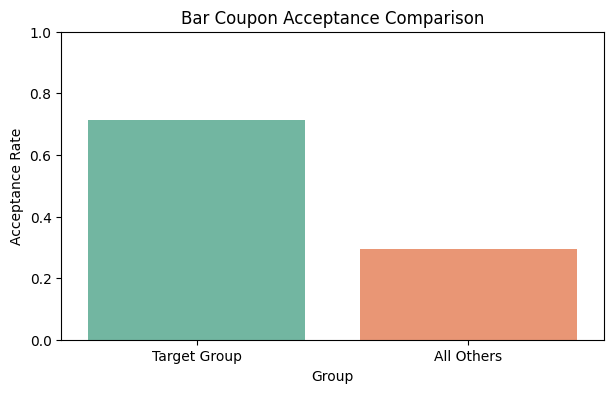

In [35]:
# Target group
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
]

# Everyone else
group2 = bar_coupons[
    ~(
        (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
        (bar_coupons['passanger'] != 'Kid(s)') &
        (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
    )
]

group1_rate = group1['Y'].mean()
group2_rate = group2['Y'].mean()

print(f"Acceptance rate (target group): {group1_rate:.2%}")
print(f"Acceptance rate (all others): {group2_rate:.2%}")

comparison_df = pd.DataFrame({
    'Group': ['Target Group', 'All Others'],
    'Acceptance Rate': [group1_rate, group2_rate]
})

plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison_df,
    x='Group',
    y='Acceptance Rate',
    palette='Set2'
)

plt.ylim(0,1)
plt.title('Bar Coupon Acceptance Comparison')
plt.ylabel('Acceptance Rate')

plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



Target group acceptance rate: 58.89%
Other group acceptance rate: 29.74%


C:\Users\Adviti Mohan\AppData\Local\Temp\ipykernel_29560\993819655.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


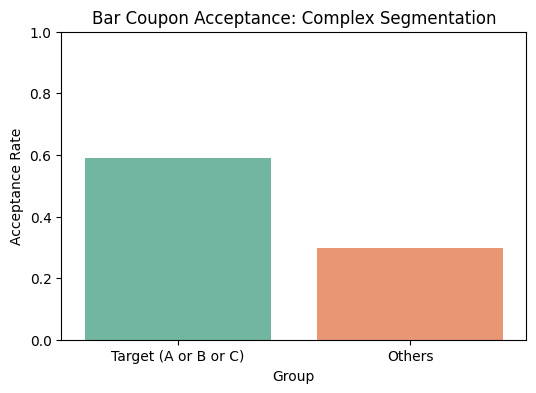

In [41]:
cond_a = (
    bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
)

young_ages = ['below21', '21', '26']

cond_b = (
    bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (bar_coupons['age'].isin(young_ages))
)

low_income = [
    'Less than $12500',
    '$12500 - $24999',
    '$25000 - $37499',
    '$37500 - $49999'
]

cond_c = (
    bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8']) &
    (bar_coupons['income'].isin(low_income))
)

target_group = bar_coupons[cond_a | cond_b | cond_c]
other_group = bar_coupons[~(cond_a | cond_b | cond_c)]
target_rate = target_group['Y'].mean()
other_rate = other_group['Y'].mean()

print(f"Target group acceptance rate: {target_rate:.2%}")
print(f"Other group acceptance rate: {other_rate:.2%}")
comparison_df = pd.DataFrame({
    'Group': ['Target (A or B or C)', 'Others'],
    'Acceptance Rate': [target_rate, other_rate]
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison_df,
    x='Group',
    y='Acceptance Rate',
    palette='Set2'
)

plt.ylim(0,1)
plt.title('Bar Coupon Acceptance: Complex Segmentation')
plt.ylabel('Acceptance Rate')

plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

C:\Users\Adviti Mohan\AppData\Local\Temp\ipykernel_29560\2165054871.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


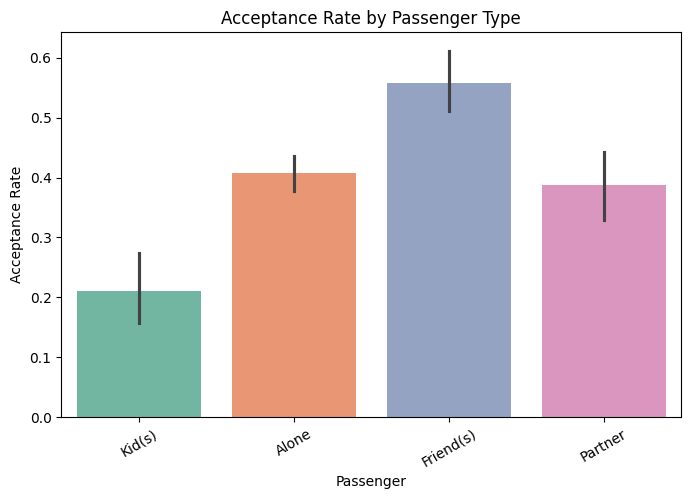

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=bar_coupons,
    x='passanger',
    y='Y',
    palette='Set2'
)

plt.title('Acceptance Rate by Passenger Type')
plt.xlabel('Passenger')
plt.ylabel('Acceptance Rate')

plt.xticks(rotation=30)

plt.show()

C:\Users\Adviti Mohan\AppData\Local\Temp\ipykernel_29560\550984506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


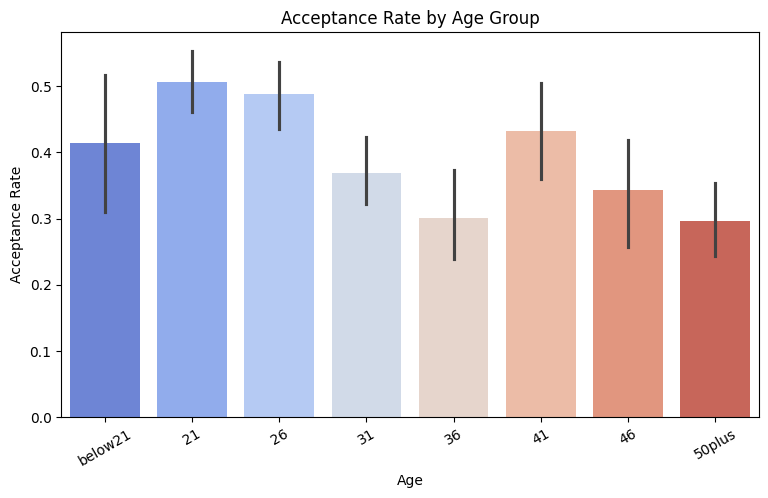

In [44]:
age_order = ['below21','21','26','31','36','41','46','50plus']

plt.figure(figsize=(9,5))

sns.barplot(
    data=bar_coupons,
    x='age',
    y='Y',
    order=age_order,
    palette='coolwarm'
)

plt.title('Acceptance Rate by Age Group')
plt.xlabel('Age')
plt.ylabel('Acceptance Rate')

plt.xticks(rotation=30)

plt.show()

C:\Users\Adviti Mohan\AppData\Local\Temp\ipykernel_29560\1841237748.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


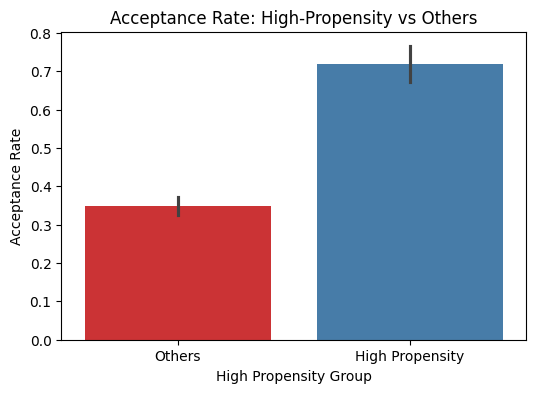

In [45]:
bar_coupons['high_propensity'] = (
    bar_coupons['Bar'].isin(['1~3','4~8','gt8']) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['age'].isin(['below21','21','26']))
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=bar_coupons,
    x='high_propensity',
    y='Y',
    palette='Set1'
)

plt.title('Acceptance Rate: High-Propensity vs Others')
plt.xlabel('High Propensity Group')
plt.ylabel('Acceptance Rate')

plt.xticks([0,1], ['Others','High Propensity'])

plt.show()

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  